In [1]:
print('hello')

hello


In [2]:
import sys
print(sys.executable)

/Users/asairyuunosuke/.pyenv/versions/3.13.1/bin/python


In [3]:
import pandas as pd

In [4]:
import sys
# 今動いているPythonに、matplotlib, seaborn, scikit-learn を全部入れます
!{sys.executable} -m pip install matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from category_encoders import TargetEncoder
import optuna
import lightgbm as lgb


/Users/asairyuunosuke/.pyenv/versions/3.13.1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
import sys
!{sys.executable} -m pip install category_encoders optuna lightgbm


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from category_encoders import TargetEncoder
import optuna
import lightgbm as lgb


In [8]:
train=pd.read_csv('train.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
test=pd.read_csv('test.csv')
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
print('train',train.shape)
print('test', test.shape)

train (891, 12)
test (418, 11)


In [12]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

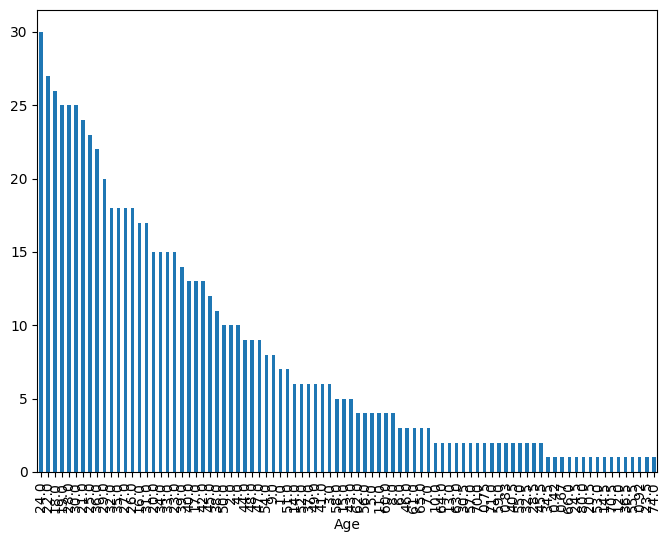

In [13]:
train_counts=train['Age'].value_counts()
plt.figure(figsize=(8,6))
train_counts.plot(kind='bar')
plt.show()

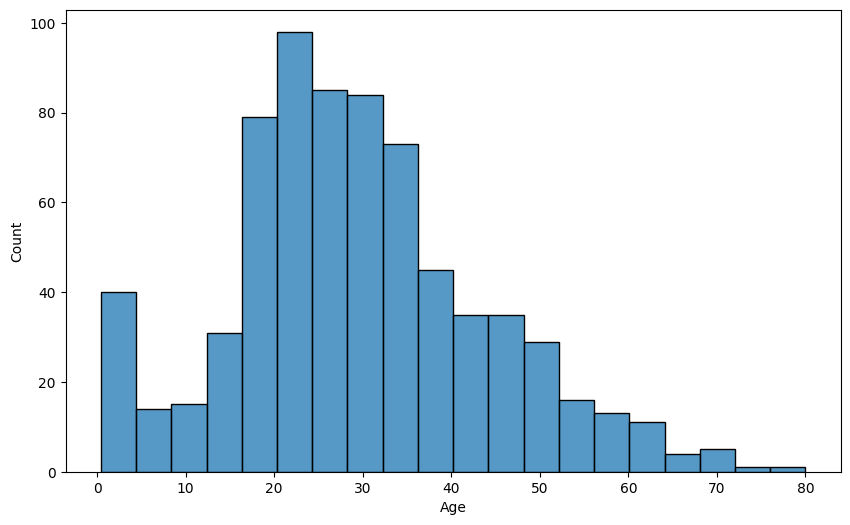

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(train['Age'], bins=20)
plt.show()

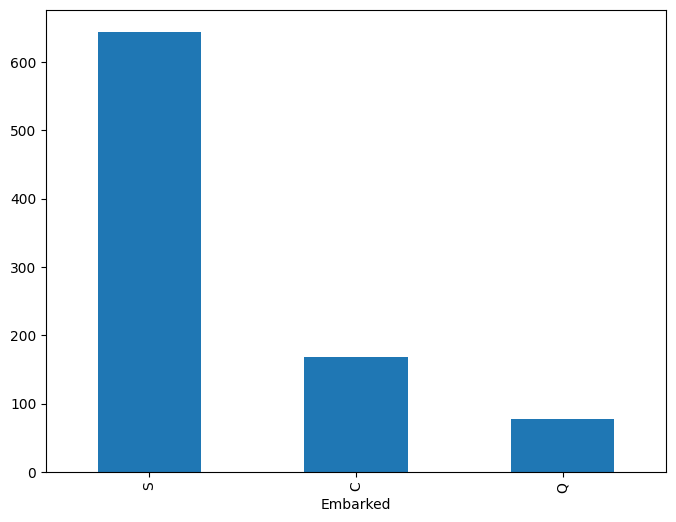

In [15]:
train_counts=train['Embarked'].value_counts()
plt.figure(figsize=(8,6))
train_counts.plot(kind='bar')
plt.show()

In [16]:
train['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [17]:
df_train=train.copy()
df_test=test.copy()

In [18]:
df_train['Age']=df_train['Age'].fillna(df_train['Age'].mean())
df_train['Embarked']=df_train['Embarked'].fillna('S')

df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [19]:
df_train=df_train.drop(['Cabin'],axis=1)

In [20]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [21]:
train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [22]:
df_train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [23]:
df_test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [24]:
X=train[['Pclass','SibSp','Parch']]
y=train[['Survived']]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train,y_test=train_test_split(X,y,random_state=0)

In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier()
knn.fit(X_train, y_train)

/Users/asairyuunosuke/.pyenv/versions/3.13.1/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [27]:
knn.score(X_test,y_test)

0.672645739910314

In [28]:
X_for_submit=test[['Pclass','SibSp','Parch']]
submit=test[['PassengerId']]
submit['Survived']=knn.predict(X_for_submit)

submit

/var/folders/q_/lrpl542n2hdcd1tf6xmqxmyc0000gn/T/ipykernel_98504/3785060912.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submit['Survived']=knn.predict(X_for_submit)


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
...,...,...
413,1305,0
414,1306,0
415,1307,0
416,1308,0


In [29]:
submit.to_csv('submit01.csv', index=False)

In [30]:
X=train[['Pclass','SibSp','Parch','Sex']]
y=train[['Survived']]

In [31]:
X=pd.get_dummies(X, columns=['Pclass','Sex'])
X

,SibSp,Parch,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male
0,1,0,False,False,True,False,True
1,1,0,True,False,False,True,False
2,0,0,False,False,True,True,False
3,1,0,True,False,False,True,False
4,0,0,False,False,True,False,True
...,...,...,...,...,...,...,...
886,0,0,False,True,False,False,True
887,0,0,True,False,False,True,False
888,1,2,False,False,True,True,False
889,0,0,True,False,False,False,True


In [32]:
X=X.astype(int)

In [33]:
X_train, X_test, y_train,y_test=train_test_split(X,y,random_state=0)

knn=KNeighborsClassifier()
knn.fit(X_train, y_train)

knn.score(X_test,y_test)

/Users/asairyuunosuke/.pyenv/versions/3.13.1/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


0.7982062780269058

In [34]:
X=train[['Pclass','SibSp','Parch','Sex','Fare']]
y=train[['Survived']]

In [35]:
X=pd.get_dummies(X, columns=['Pclass','Sex'])
X

,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male
0,1,0,7.2500,False,False,True,False,True
1,1,0,71.2833,True,False,False,True,False
2,0,0,7.9250,False,False,True,True,False
3,1,0,53.1000,True,False,False,True,False
4,0,0,8.0500,False,False,True,False,True
...,...,...,...,...,...,...,...,...
886,0,0,13.0000,False,True,False,False,True
887,0,0,30.0000,True,False,False,True,False
888,1,2,23.4500,False,False,True,True,False
889,0,0,30.0000,True,False,False,False,True


In [36]:
X=X.astype(int)

In [37]:
X_train, X_test, y_train,y_test=train_test_split(X,y,random_state=0)

knn=KNeighborsClassifier()
knn.fit(X_train, y_train)

knn.score(X_test,y_test)

/Users/asairyuunosuke/.pyenv/versions/3.13.1/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


0.7982062780269058

In [38]:
# 標準化
from sklearn.preprocessing import StandardScaler

scaler =StandardScaler()
scaler.fit(X_train)

X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

knn=KNeighborsClassifier()
knn.fit(X_train, y_train)

knn.score(X_test,y_test)

/Users/asairyuunosuke/.pyenv/versions/3.13.1/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


0.7982062780269058

In [39]:
X

,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male
0,1,0,7,0,0,1,0,1
1,1,0,71,1,0,0,1,0
2,0,0,7,0,0,1,1,0
3,1,0,53,1,0,0,1,0
4,0,0,8,0,0,1,0,1
...,...,...,...,...,...,...,...,...
886,0,0,13,0,1,0,0,1
887,0,0,30,1,0,0,1,0
888,1,2,23,0,0,1,1,0
889,0,0,30,1,0,0,0,1


In [40]:
X_for_submit=test[['Pclass','SibSp','Parch','Sex','Fare']]
submit = test[['PassengerId']]

X_for_submit=pd.get_dummies(X_for_submit, columns=['Pclass','Sex'])

#欠損値
X_for_submit['Fare']=X_for_submit['Fare'].fillna(X_for_submit['Fare'].mean())

scaler =StandardScaler()
scaler.fit(X_for_submit)#ここを消す→テストデータでの標準化なので。trainとは異なるものに→さらに精度が上がることも

X_for_submit_scaled=scaler.transform(X_for_submit)

submit['Survived'] =knn.predict(X_for_submit)
submit

/var/folders/q_/lrpl542n2hdcd1tf6xmqxmyc0000gn/T/ipykernel_98504/1475473413.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submit['Survived'] =knn.predict(X_for_submit)


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [41]:
submit.to_csv('submit02.csv', index=False)

In [42]:
X=train[['Pclass','SibSp','Parch','Sex','Fare']]
y=train[['Survived']]

X=pd.get_dummies(X, columns=['Pclass','Sex'])

X_train, X_test, y_train,y_test=train_test_split(X,y,random_state=0)

scaler =StandardScaler()
scaler.fit(X_train)

X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [43]:
from sklearn.svm import LinearSVC

svc=LinearSVC()
svc.fit(X_train_scaled,y_train)

svc.score(X_test_scaled, y_test)

/Users/asairyuunosuke/.pyenv/versions/3.13.1/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.7847533632286996

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train_scaled,y_train)

rf.score(X_test_scaled, y_test)

/Users/asairyuunosuke/.pyenv/versions/3.13.1/lib/python3.13/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.8251121076233184

In [45]:
from sklearn.ensemble import GradientBoostingClassifier

gbrt=GradientBoostingClassifier()
gbrt.fit(X_train_scaled,y_train)

gbrt.score(X_test_scaled, y_test)

/Users/asairyuunosuke/.pyenv/versions/3.13.1/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.8026905829596412

In [46]:
X_for_submit=test[['Pclass','SibSp','Parch','Sex','Fare']]
submit=test[['PassengerId']]

X_for_submit=pd.get_dummies(X_for_submit, columns=['Pclass','Sex'])

X_for_submit['Fare']=X_for_submit['Fare'].fillna(X_for_submit['Fare'].mean())


X_for_submit_scaled=scaler.transform(X_for_submit)


submit['Survived']=rf.predict(X_for_submit_scaled)
submit

/var/folders/q_/lrpl542n2hdcd1tf6xmqxmyc0000gn/T/ipykernel_98504/3351306543.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submit['Survived']=rf.predict(X_for_submit_scaled)


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [47]:
submit.to_csv('submit03.csv', index=False)

In [48]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [49]:
df_train.describe(include=['O'])#→OはObject（文字）の統計を見るために

,Name,Sex,Ticket,Embarked
count,891,891,891,891
unique,891,2,681,3
top,"Braund, Mr. Owen Harris",male,347082,S
freq,1,577,7,646


In [50]:
df_train[['Pclass', 'Survived']].groupby(['Pclass'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [51]:
df_train[["Sex", "Survived"]].groupby(['Sex'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [52]:
df_train[["SibSp", "Survived"]].groupby(['SibSp'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,SibSp,Survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [53]:
df_train[["Parch", "Survived"]].groupby(['Parch'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


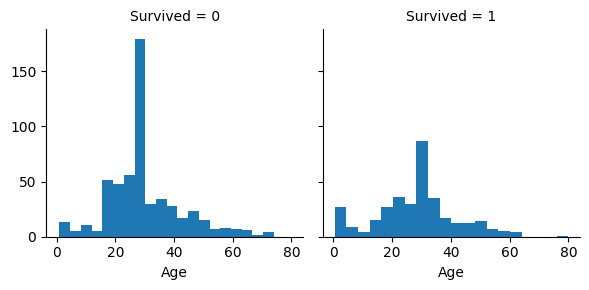

In [54]:
g = sns.FacetGrid(df_train, col='Survived')
g.map(plt.hist, 'Age', bins=20)

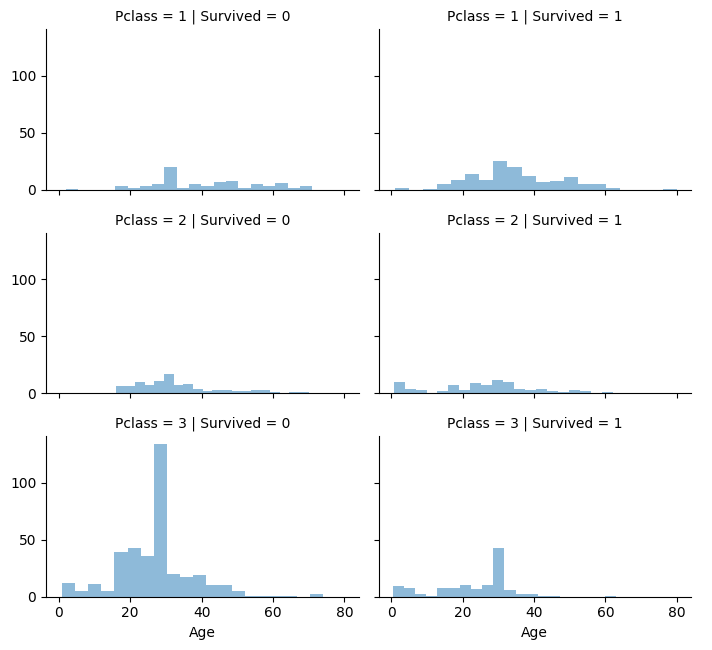

In [55]:
grid = sns.FacetGrid(df_train, col='Survived', row='Pclass', height=2.2, aspect=1.6)
grid.map(plt.hist, 'Age', alpha=.5, bins=20)
grid.add_legend();

/Users/asairyuunosuke/.pyenv/versions/3.13.1/lib/python3.13/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/Users/asairyuunosuke/.pyenv/versions/3.13.1/lib/python3.13/site-packages/seaborn/axisgrid.py:723: UserWarning: Using the pointplot function without specifying `hue_order` is likely to produce an incorrect plot.
  warnings.warn(warning)


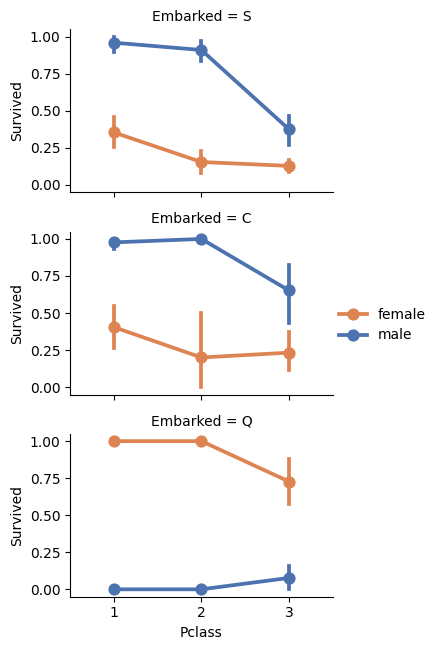

In [56]:
grid = sns.FacetGrid(df_train, row='Embarked', height=2.2, aspect=1.6)
grid.map(sns.pointplot, 'Pclass', 'Survived', 'Sex', palette='deep')
grid.add_legend()

/Users/asairyuunosuke/.pyenv/versions/3.13.1/lib/python3.13/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/Users/asairyuunosuke/.pyenv/versions/3.13.1/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/asairyuunosuke/.pyenv/versions/3.13.1/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/asairyuunosuke/.pyenv/versions/3.13.1/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/Users/asairyuunosuke/.pyenv/versions/3.13.1/lib/python3.13/site-packages/seaborn/axisgrid.

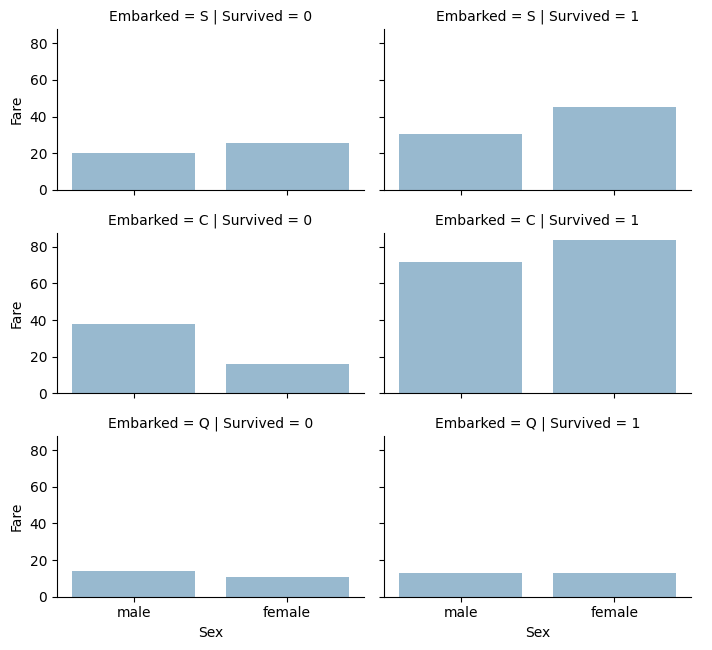

In [57]:
grid = sns.FacetGrid(df_train, row='Embarked', col='Survived', height=2.2, aspect=1.6)
grid.map(sns.barplot, 'Sex', 'Fare', alpha=.5, ci=None)
grid.add_legend()

In [58]:
combine = [df_train, df_test]
for dateset in combine:
    dateset['Title']=dateset.Name.str.extract('([A-Za-z]+)\.',expand=False )
pd.crosstab(df_train['Title'],df_train['Sex'])

<>:3: SyntaxWarning: invalid escape sequence '\.'
<>:3: SyntaxWarning: invalid escape sequence '\.'
/var/folders/q_/lrpl542n2hdcd1tf6xmqxmyc0000gn/T/ipykernel_98504/3968708317.py:3: SyntaxWarning: invalid escape sequence '\.'
  dateset['Title']=dateset.Name.str.extract('([A-Za-z]+)\.',expand=False )


Sex,female,male
Title,,
Capt,0,1
Col,0,2
Countess,1,0
Don,0,1
Dr,1,6
Jonkheer,0,1
Lady,1,0
Major,0,2
Master,0,40


In [59]:
for dataset in combine:
    dataset['Title'] = dataset['Title'].replace(['Lady', 'Countess','Capt', 'Col',\
 	'Don', 'Major', 'Dr', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')

    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')
    
df_train[['Title', 'Survived']].groupby(['Title'], as_index=False).mean().sort_values(by='Survived',ascending=False)

,Title,Survived
3,Mrs,0.793651
1,Miss,0.702703
0,Master,0.575000
4,Rare,0.347826
2,Mr,0.156673


In [60]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
 11  Title        891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [61]:
df_train['AgeBand']=pd.cut(df_train['Age'],5)
df_train[['AgeBand','Survived']].groupby(['AgeBand'], as_index=False).mean().sort_values(by='AgeBand', ascending=True)


/var/folders/q_/lrpl542n2hdcd1tf6xmqxmyc0000gn/T/ipykernel_98504/2346988883.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_train[['AgeBand','Survived']].groupby(['AgeBand'], as_index=False).mean().sort_values(by='AgeBand', ascending=True)


,AgeBand,Survived
0,"(0.34, 16.336]",0.550000
1,"(16.336, 32.252]",0.344168
2,"(32.252, 48.168]",0.404255
3,"(48.168, 64.084]",0.434783
4,"(64.084, 80.0]",0.090909


In [62]:
combine=[df_train, df_test]
for dataset in combine:
    dataset.loc[dataset['Age']<=16, 'Age']=0
    dataset.loc[(dataset['Age'] > 16) & (dataset['Age'] <= 32), 'Age'] = 1
    dataset.loc[(dataset['Age'] > 32) & (dataset['Age'] <= 48), 'Age'] = 2
    dataset.loc[(dataset['Age'] > 48) & (dataset['Age'] <= 64), 'Age'] = 3
    dataset.loc[ dataset['Age'] > 64, 'Age'] = 4
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,AgeBand
0,1,0,3,"Braund, Mr. Owen Harris",male,1.0,1,0,A/5 21171,7.2500,S,Mr,"(16.336, 32.252]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,2.0,1,0,PC 17599,71.2833,C,Mrs,"(32.252, 48.168]"
2,3,1,3,"Heikkinen, Miss. Laina",female,1.0,0,0,STON/O2. 3101282,7.9250,S,Miss,"(16.336, 32.252]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,2.0,1,0,113803,53.1000,S,Mrs,"(32.252, 48.168]"
4,5,0,3,"Allen, Mr. William Henry",male,2.0,0,0,373450,8.0500,S,Mr,"(32.252, 48.168]"


In [63]:
for dataset in combine:
    dataset['Embarked']=dataset['Embarked'].fillna('S')
    
    dataset['Embarked']=dataset['Embarked'].map({'S':0,'C':1, 'Q':2}).astype(int)
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,AgeBand
0,1,0,3,"Braund, Mr. Owen Harris",male,1.0,1,0,A/5 21171,7.2500,0,Mr,"(16.336, 32.252]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,2.0,1,0,PC 17599,71.2833,1,Mrs,"(32.252, 48.168]"
2,3,1,3,"Heikkinen, Miss. Laina",female,1.0,0,0,STON/O2. 3101282,7.9250,0,Miss,"(16.336, 32.252]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,2.0,1,0,113803,53.1000,0,Mrs,"(32.252, 48.168]"
4,5,0,3,"Allen, Mr. William Henry",male,2.0,0,0,373450,8.0500,0,Mr,"(32.252, 48.168]"


In [64]:
df_train['Embarked'].unique()

array([0, 1, 2])

In [65]:
for dataset in combine:
    dataset['FamilySize']=dataset['SibSp']+dataset['Parch']+1
df_train[['FamilySize', 'Survived']].groupby(['FamilySize'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,FamilySize,Survived
3,4,0.724138
2,3,0.578431
1,2,0.552795
6,7,0.333333
0,1,0.303538
4,5,0.200000
5,6,0.136364
7,8,0.000000
8,11,0.000000


In [66]:
for dataset in combine:
    dataset['IsAlone'] = 0
    dataset.loc[dataset['FamilySize'] == 1, 'IsAlone'] =1
    
df_train[['IsAlone', 'Survived']].groupby(['IsAlone'], as_index=False).mean()

,IsAlone,Survived
0,0,0.505650
1,1,0.303538


In [67]:
df_train['FareBand']=pd.qcut(df_train['Fare'], 4)
df_train[['FareBand', 'Survived']].groupby(['FareBand'], as_index=False).mean().sort_values(by='Survived', ascending=False)

/var/folders/q_/lrpl542n2hdcd1tf6xmqxmyc0000gn/T/ipykernel_98504/1384624066.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_train[['FareBand', 'Survived']].groupby(['FareBand'], as_index=False).mean().sort_values(by='Survived', ascending=False)


,FareBand,Survived
3,"(31.0, 512.329]",0.581081
2,"(14.454, 31.0]",0.454955
1,"(7.91, 14.454]",0.303571
0,"(-0.001, 7.91]",0.197309


In [68]:
df_test['Fare'].fillna(df_test['Fare'].dropna().median(), inplace=True)

for dataset in combine:
    dataset.loc[ dataset['Fare'] <= 7.91, 'Fare'] = 0
    dataset.loc[(dataset['Fare'] > 7.91) & (dataset['Fare'] <= 14.454), 'Fare'] = 1
    dataset.loc[(dataset['Fare'] > 14.454) & (dataset['Fare'] <= 31), 'Fare']   = 2
    dataset.loc[ dataset['Fare'] > 31, 'Fare'] = 3
    dataset['Fare'] = dataset['Fare'].astype(int)

df_train = df_train.drop(['FareBand'], axis=1)

df_train.head(10)

/var/folders/q_/lrpl542n2hdcd1tf6xmqxmyc0000gn/T/ipykernel_98504/257269037.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test['Fare'].fillna(df_test['Fare'].dropna().median(), inplace=True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,AgeBand,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,1.0,1,0,A/5 21171,0,0,Mr,"(16.336, 32.252]",2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,2.0,1,0,PC 17599,3,1,Mrs,"(32.252, 48.168]",2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,1.0,0,0,STON/O2. 3101282,1,0,Miss,"(16.336, 32.252]",1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,2.0,1,0,113803,3,0,Mrs,"(32.252, 48.168]",2,0
4,5,0,3,"Allen, Mr. William Henry",male,2.0,0,0,373450,1,0,Mr,"(32.252, 48.168]",1,1
5,6,0,3,"Moran, Mr. James",male,1.0,0,0,330877,1,2,Mr,"(16.336, 32.252]",1,1
6,7,0,1,"McCarthy, Mr. Timothy J",male,3.0,0,0,17463,3,0,Mr,"(48.168, 64.084]",1,1
7,8,0,3,"Palsson, Master. Gosta Leonard",male,0.0,3,1,349909,2,0,Master,"(0.34, 16.336]",5,0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,1.0,0,2,347742,1,0,Mrs,"(16.336, 32.252]",3,0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,0.0,1,0,237736,2,1,Mrs,"(0.34, 16.336]",2,0


In [69]:
for dataset in combine:    
    dataset.loc[ dataset['Age'] <= 16, 'Age'] = 0
    dataset.loc[(dataset['Age'] > 16) & (dataset['Age'] <= 32), 'Age'] = 1
    dataset.loc[(dataset['Age'] > 32) & (dataset['Age'] <= 48), 'Age'] = 2
    dataset.loc[(dataset['Age'] > 48) & (dataset['Age'] <= 64), 'Age'] = 3
    dataset.loc[ dataset['Age'] > 64, 'Age']=4
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,AgeBand,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,1.0,1,0,A/5 21171,0,0,Mr,"(16.336, 32.252]",2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,2.0,1,0,PC 17599,3,1,Mrs,"(32.252, 48.168]",2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,1.0,0,0,STON/O2. 3101282,1,0,Miss,"(16.336, 32.252]",1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,2.0,1,0,113803,3,0,Mrs,"(32.252, 48.168]",2,0
4,5,0,3,"Allen, Mr. William Henry",male,2.0,0,0,373450,1,0,Mr,"(32.252, 48.168]",1,1


In [70]:
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
for dataset in combine:
    dataset['Title'] = dataset['Title'].map(title_mapping)
    dataset['Title'] = dataset['Title'].fillna(0)

df_train['Title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Rare'], dtype=object)

In [71]:
df_train=df_train.drop(['Parch', 'SibSp', 'FamilySize','AgeBand'], axis=1)
df_test=df_test.drop(['Parch', 'SibSp', 'FamilySize'], axis=1)

df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Title,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,1.0,A/5 21171,0,0,Mr,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,2.0,PC 17599,3,1,Mrs,0
2,3,1,3,"Heikkinen, Miss. Laina",female,1.0,STON/O2. 3101282,1,0,Miss,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,2.0,113803,3,0,Mrs,0
4,5,0,3,"Allen, Mr. William Henry",male,2.0,373450,1,0,Mr,1


In [72]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   Ticket       891 non-null    object 
 7   Fare         891 non-null    int64  
 8   Embarked     891 non-null    int64  
 9   Title        891 non-null    object 
 10  IsAlone      891 non-null    int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 76.7+ KB


In [73]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Title,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,1.0,A/5 21171,0,0,Mr,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,2.0,PC 17599,3,1,Mrs,0
2,3,1,3,"Heikkinen, Miss. Laina",female,1.0,STON/O2. 3101282,1,0,Miss,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,2.0,113803,3,0,Mrs,0
4,5,0,3,"Allen, Mr. William Henry",male,2.0,373450,1,0,Mr,1


In [74]:
combine = [df_train, df_test]#combineの更新
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
for dataset in combine:
    dataset['Title'] = dataset['Title'].map(title_mapping)
    dataset['Title'] = dataset['Title'].fillna(0)

df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Title,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,1.0,A/5 21171,0,0,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,2.0,PC 17599,3,1,3,0
2,3,1,3,"Heikkinen, Miss. Laina",female,1.0,STON/O2. 3101282,1,0,2,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,2.0,113803,3,0,3,0
4,5,0,3,"Allen, Mr. William Henry",male,2.0,373450,1,0,1,1


In [75]:
for dataset in combine:
    dataset['Sex'] = dataset['Sex'].map( {'female': 1, 'male': 0} ).astype(int)

df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Title,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",0,1.0,A/5 21171,0,0,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,2.0,PC 17599,3,1,3,0
2,3,1,3,"Heikkinen, Miss. Laina",1,1.0,STON/O2. 3101282,1,0,2,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,2.0,113803,3,0,3,0
4,5,0,3,"Allen, Mr. William Henry",0,2.0,373450,1,0,1,1


In [76]:
df_train=df_train.drop(['Name'], axis=1)
df_test=df_test.drop(['Name'], axis=1)

df_train.head()

,PassengerId,Survived,Pclass,Sex,Age,Ticket,Fare,Embarked,Title,IsAlone
0,1,0,3,0,1.0,A/5 21171,0,0,1,0
1,2,1,1,1,2.0,PC 17599,3,1,3,0
2,3,1,3,1,1.0,STON/O2. 3101282,1,0,2,1
3,4,1,1,1,2.0,113803,3,0,3,0
4,5,0,3,0,2.0,373450,1,0,1,1


In [77]:
df_train=df_train.drop(['Ticket'], axis=1)
df_test=df_test.drop(['Ticket'], axis=1)

df_train.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,Title,IsAlone
0,1,0,3,0,1.0,0,0,1,0
1,2,1,1,1,2.0,3,1,3,0
2,3,1,3,1,1.0,1,0,2,1
3,4,1,1,1,2.0,3,0,3,0
4,5,0,3,0,2.0,1,0,1,1


In [78]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    int64  
 4   Age          891 non-null    float64
 5   Fare         891 non-null    int64  
 6   Embarked     891 non-null    int64  
 7   Title        891 non-null    int64  
 8   IsAlone      891 non-null    int64  
dtypes: float64(1), int64(8)
memory usage: 62.8 KB


In [79]:
df_test.head()

,PassengerId,Pclass,Sex,Age,Fare,Cabin,Embarked,Title,IsAlone
0,892,3,0,0.0,0,NaN,2,0.0,1
1,893,3,1,0.0,0,NaN,0,0.0,0
2,894,2,0,0.0,1,NaN,2,0.0,1
3,895,3,0,0.0,1,NaN,0,0.0,1
4,896,3,1,0.0,1,NaN,0,0.0,0


In [95]:
df_train['Age']=df_train['Age'].astype(int)

df_test['Age']=df_test['Age'].fillna(df_test['Age'].mean()).astype(int)
df_test['Title']=df_test['Title'].astype(int)
#df_test=df_test.drop(['Cabin'], axis=1)
#df_train=df_train.drop(['PassengerId'], axis=1)


In [96]:
df_train.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,Title,IsAlone
0,1,0,3,0,1,0,0,1,0
1,2,1,1,1,2,3,1,3,0
2,3,1,3,1,1,1,0,2,1
3,4,1,1,1,2,3,0,3,0
4,5,0,3,0,2,1,0,1,1


In [97]:
df_test.head()

,PassengerId,Pclass,Sex,Age,Fare,Embarked,Title,IsAlone
0,892,3,0,0,0,2,0,1
1,893,3,1,0,0,0,0,0
2,894,2,0,0,1,2,0,1
3,895,3,0,0,1,0,0,1
4,896,3,1,0,1,0,0,0


In [101]:
X_train = df_train.drop(["Survived", "PassengerId"], axis=1)
Y_train = df_train["Survived"]
X_test  = df_test.drop(["PassengerId"], axis=1).copy()
X_train.shape, Y_train.shape, X_test.shape

((891, 7), (891,), (418, 7))

In [104]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(X_train, Y_train)
Y_pred = logreg.predict(X_test)
acc_log = round(logreg.score(X_train, Y_train)*100, 2)
acc_log
print(f"Accuracy: {acc_log}")

Accuracy: 80.47


In [106]:
# Support Vector Machines
from sklearn.svm import SVC

svc = SVC()
svc.fit(X_train, Y_train)
Y_pred = svc.predict(X_test)
acc_svc = round(svc.score(X_train, Y_train) * 100, 2)
print(f"Accuracy: {acc_svc}")

Accuracy: 83.28


In [107]:
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train, Y_train)
Y_pred = knn.predict(X_test)
acc_knn = round(knn.score(X_train, Y_train) * 100, 2)
print(f"Accuracy: {acc_knn}")

Accuracy: 84.96


In [109]:
from sklearn.naive_bayes import GaussianNB

# Gaussian Naive Bayes

gaussian = GaussianNB()
gaussian.fit(X_train, Y_train)
Y_pred = gaussian.predict(X_test)
acc_gaussian = round(gaussian.score(X_train, Y_train) * 100, 2)
print(f"Accuracy: {acc_gaussian}")

Accuracy: 77.33


In [112]:
# Perceptron
from sklearn.linear_model import Perceptron

perceptron = Perceptron()
perceptron.fit(X_train, Y_train)
Y_pred = perceptron.predict(X_test)
acc_perceptron = round(perceptron.score(X_train, Y_train) * 100, 2)
print(f"Accuracy: {acc_perceptron}")

Accuracy: 79.91


In [113]:
# Linear SVC

linear_svc = LinearSVC()
linear_svc.fit(X_train, Y_train)
Y_pred = linear_svc.predict(X_test)
acc_linear_svc = round(linear_svc.score(X_train, Y_train) * 100, 2)
print(f"Accuracy: {acc_linear_svc}")

Accuracy: 79.46


In [115]:
# Stochastic Gradient Descent
from sklearn.linear_model import SGDClassifier
sgd = SGDClassifier()
sgd.fit(X_train, Y_train)
Y_pred = sgd.predict(X_test)
acc_sgd = round(sgd.score(X_train, Y_train) * 100, 2)
print(f"Accuracy: {acc_sgd}")


Accuracy: 73.63


In [117]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, Y_train)
Y_pred = decision_tree.predict(X_test)
acc_decision_tree = round(decision_tree.score(X_train, Y_train) * 100, 2)
print(f"Accuracy: {acc_decision_tree}")

Accuracy: 86.87


In [118]:
# Random Forest

random_forest = RandomForestClassifier(n_estimators=100)
random_forest.fit(X_train, Y_train)
Y_pred = random_forest.predict(X_test)
random_forest.score(X_train, Y_train)
acc_random_forest = round(random_forest.score(X_train, Y_train) * 100, 2)
print(f"Accuracy: {acc_random_forest}")

Accuracy: 86.87


In [119]:
models = pd.DataFrame({
    'Model': ['Support Vector Machines', 'KNN', 'Logistic Regression', 
              'Random Forest', 'Naive Bayes', 'Perceptron', 
              'Stochastic Gradient Decent', 'Linear SVC', 
              'Decision Tree'],
    'Score': [acc_svc, acc_knn, acc_log, 
              acc_random_forest, acc_gaussian, acc_perceptron, 
              acc_sgd, acc_linear_svc, acc_decision_tree]})
models.sort_values(by='Score', ascending=False)

,Model,Score
3,Random Forest,86.87
8,Decision Tree,86.87
1,KNN,84.96
0,Support Vector Machines,83.28
2,Logistic Regression,80.47
5,Perceptron,79.91
7,Linear SVC,79.46
4,Naive Bayes,77.33
6,Stochastic Gradient Decent,73.63


In [121]:
submit = pd.DataFrame({
        "PassengerId": df_test["PassengerId"],
        "Survived": Y_pred
    })
submit.to_csv('submit04.csv', index=False)